## Imports

In [15]:
%load_ext autoreload
%autoreload 2

from ageing_packages.SR_models import SR_sim, SR_plotting
from ageing_packages.utils import sr_utils as utils
from ageing_packages.hetero_analysis import correlation_analysis as ca
from ageing_packages.hetero_analysis import twin_analysis as ta
from ageing_packages.hetero_analysis import survival_analysis as sa
from ageing_packages.hetero_analysis import hetero_plotting as hp
from ageing_packages.mortality_data_analysis import HMD
from ageing_packages.mortality_models.gamma_gompertz import GammaGompertz as gg
from ageing_packages.hetero_analysis import nhanes_analysis as nhanes

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.colors as mcolors
import pickle

def remove_top_right_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()            
    ax.get_yaxis().tick_left()
# Apply this to all future plots
plt.rc('axes', facecolor='white')
plt.rc('axes.spines', top=False, right=False)
plt.rc('axes', grid=False)

# Make tick sizes and labels 1.5 times bigger
plt.rc('xtick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('ytick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('xtick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('ytick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('xtick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('ytick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('xtick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger
plt.rc('ytick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger

# === Ensures vector elements for PDF output ===
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # Ensures TrueType fonts, which stay as text
mpl.rcParams['ps.fonttype'] = 42   # Ensures TrueType fonts for PS as well
mpl.rcParams['svg.fonttype'] = 'none'  # Use system fonts in SVG, keep elements editable

# This helps ensure that paths, shapes, and lines are saved as actual vectors.
# To maximize editability, avoid raster/bitmap elements in figures.
# When saving, use:
# plt.savefig('figure.pdf', format='pdf', dpi=300)  # dpi has effect only for raster, not vector elements.
# If you use raster images (e.g., imshow, pcolormesh), consider vector alternatives or set rasterized=True only for those artists.

# Configure plotly defaults
pio.templates.default = "plotly_white"
pio.templates["plotly_white"].layout.update(
    paper_bgcolor='white',
    plot_bgcolor='white',
    xaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    ),
    yaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    )
)

import pingouin as pg
import pandas as pd
from scipy import interpolate
from scipy.stats import gaussian_kde, gennorm, norm, gamma, beta
import seaborn as sns
import matplotlib.cm as cm
import sys, os, importlib, warnings, pickle
from scipy.stats import pearsonr
from lifelines import KaplanMeierFitter
import thresholds_functions as th

import matplotlib.path as mpath
import matplotlib.patches as mpatches

def curly_arrow(start, end, arr_size = 1, n = 5, col='gray', linew=1., width = 0.1, ax=None):
    # NOTE: Added ax as argument to avoid NameError
    xmin, ymin = start
    xmax, ymax = end
    dist = np.sqrt((xmin - xmax)**2 + (ymin - ymax)**2)
    n0 = dist / (2 * np.pi)
    
    x = np.linspace(0, dist, 151) + xmin
    y = width * np.sin(n * x / n0) + ymin
    line = plt.Line2D(x, y, color=col, lw=linew)
    
    del_x = xmax - xmin
    del_y = ymax - ymin
    ang = np.arctan2(del_y, del_x)
    
    if ax is None:
        ax = plt.gca()
    line.set_transform(mpl.transforms.Affine2D().rotate_around(xmin, ymin, ang) + ax.transData)
    ax.add_line(line)

    verts = np.array([[0,1],[0,-1],[2,0],[0,1]]).astype(float) * arr_size
    verts[:,1] += ymax
    verts[:,0] += xmax
    path = mpath.Path(verts)
    patch = mpatches.PathPatch(path, fc=col, ec=col)

    patch.set_transform(mpl.transforms.Affine2D().rotate_around(xmax, ymax, ang) + ax.transData)
    return patch


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### creating sims for plots 

In [64]:
# Load baseline parameters and setup
n = int(1e6)

base_dict = utils.load_baseline_human_params_dict()
base_dict['Xc'] = 1.08 * base_dict['Xc']
base_dict['eta'] = 1.26 * base_dict['eta']
base_dict['beta'] = 1.17 * base_dict['beta']

# Create single simulation with Xc heterogeneity
param_dict_Xc = utils.create_param_distribution_dict(
    params='Xc', 
    std=0.2, 
    n=n, 
    dist_type='gaussian', 
    params_dict=base_dict, 
    family='None'
)
Xc_sim = utils.create_sr_simulation(params_dict=param_dict_Xc, n=n, parallel=True, tmax=300, break_early=True)
print("Xc simulation completed!")

# Create single simulation with eta heterogeneity
param_dict_eta = utils.create_param_distribution_dict(
    params='eta', 
    std=0.2, 
    n=n, 
    dist_type='gaussian', 
    params_dict=base_dict, 
    family='None'
)
eta_sim = utils.create_sr_simulation(params_dict=param_dict_eta, n=n, parallel=True, tmax=300, break_early=True)
print("eta simulation completed!")

# Create single simulation with beta heterogeneity
param_dict_beta = utils.create_param_distribution_dict(
    params='beta', 
    std=0.2, 
    n=n, 
    dist_type='gaussian', 
    params_dict=base_dict, 
    family='None'
)
beta_sim = utils.create_sr_simulation(params_dict=param_dict_beta, n=n, parallel=True, tmax=300, break_early=True)
print("beta simulation completed!")

# Create single simulation with epsilon heterogeneity
param_dict_epsilon = utils.create_param_distribution_dict(
    params='epsilon', 
    std=0.2, 
    n=n, 
    dist_type='gaussian', 
    params_dict=base_dict, 
    family='None'
)
epsilon_sim = utils.create_sr_simulation(params_dict=param_dict_epsilon, n=n, parallel=True, tmax=300, break_early=True)
print("epsilon simulation completed!")

eta_plotter = SR_plotting(eta_sim)
beta_plotter = SR_plotting(beta_sim)
epsilon_plotter = SR_plotting(epsilon_sim)
Xc_plotter = SR_plotting(Xc_sim)


Xc simulation completed!
eta simulation completed!
beta simulation completed!
epsilon simulation completed!


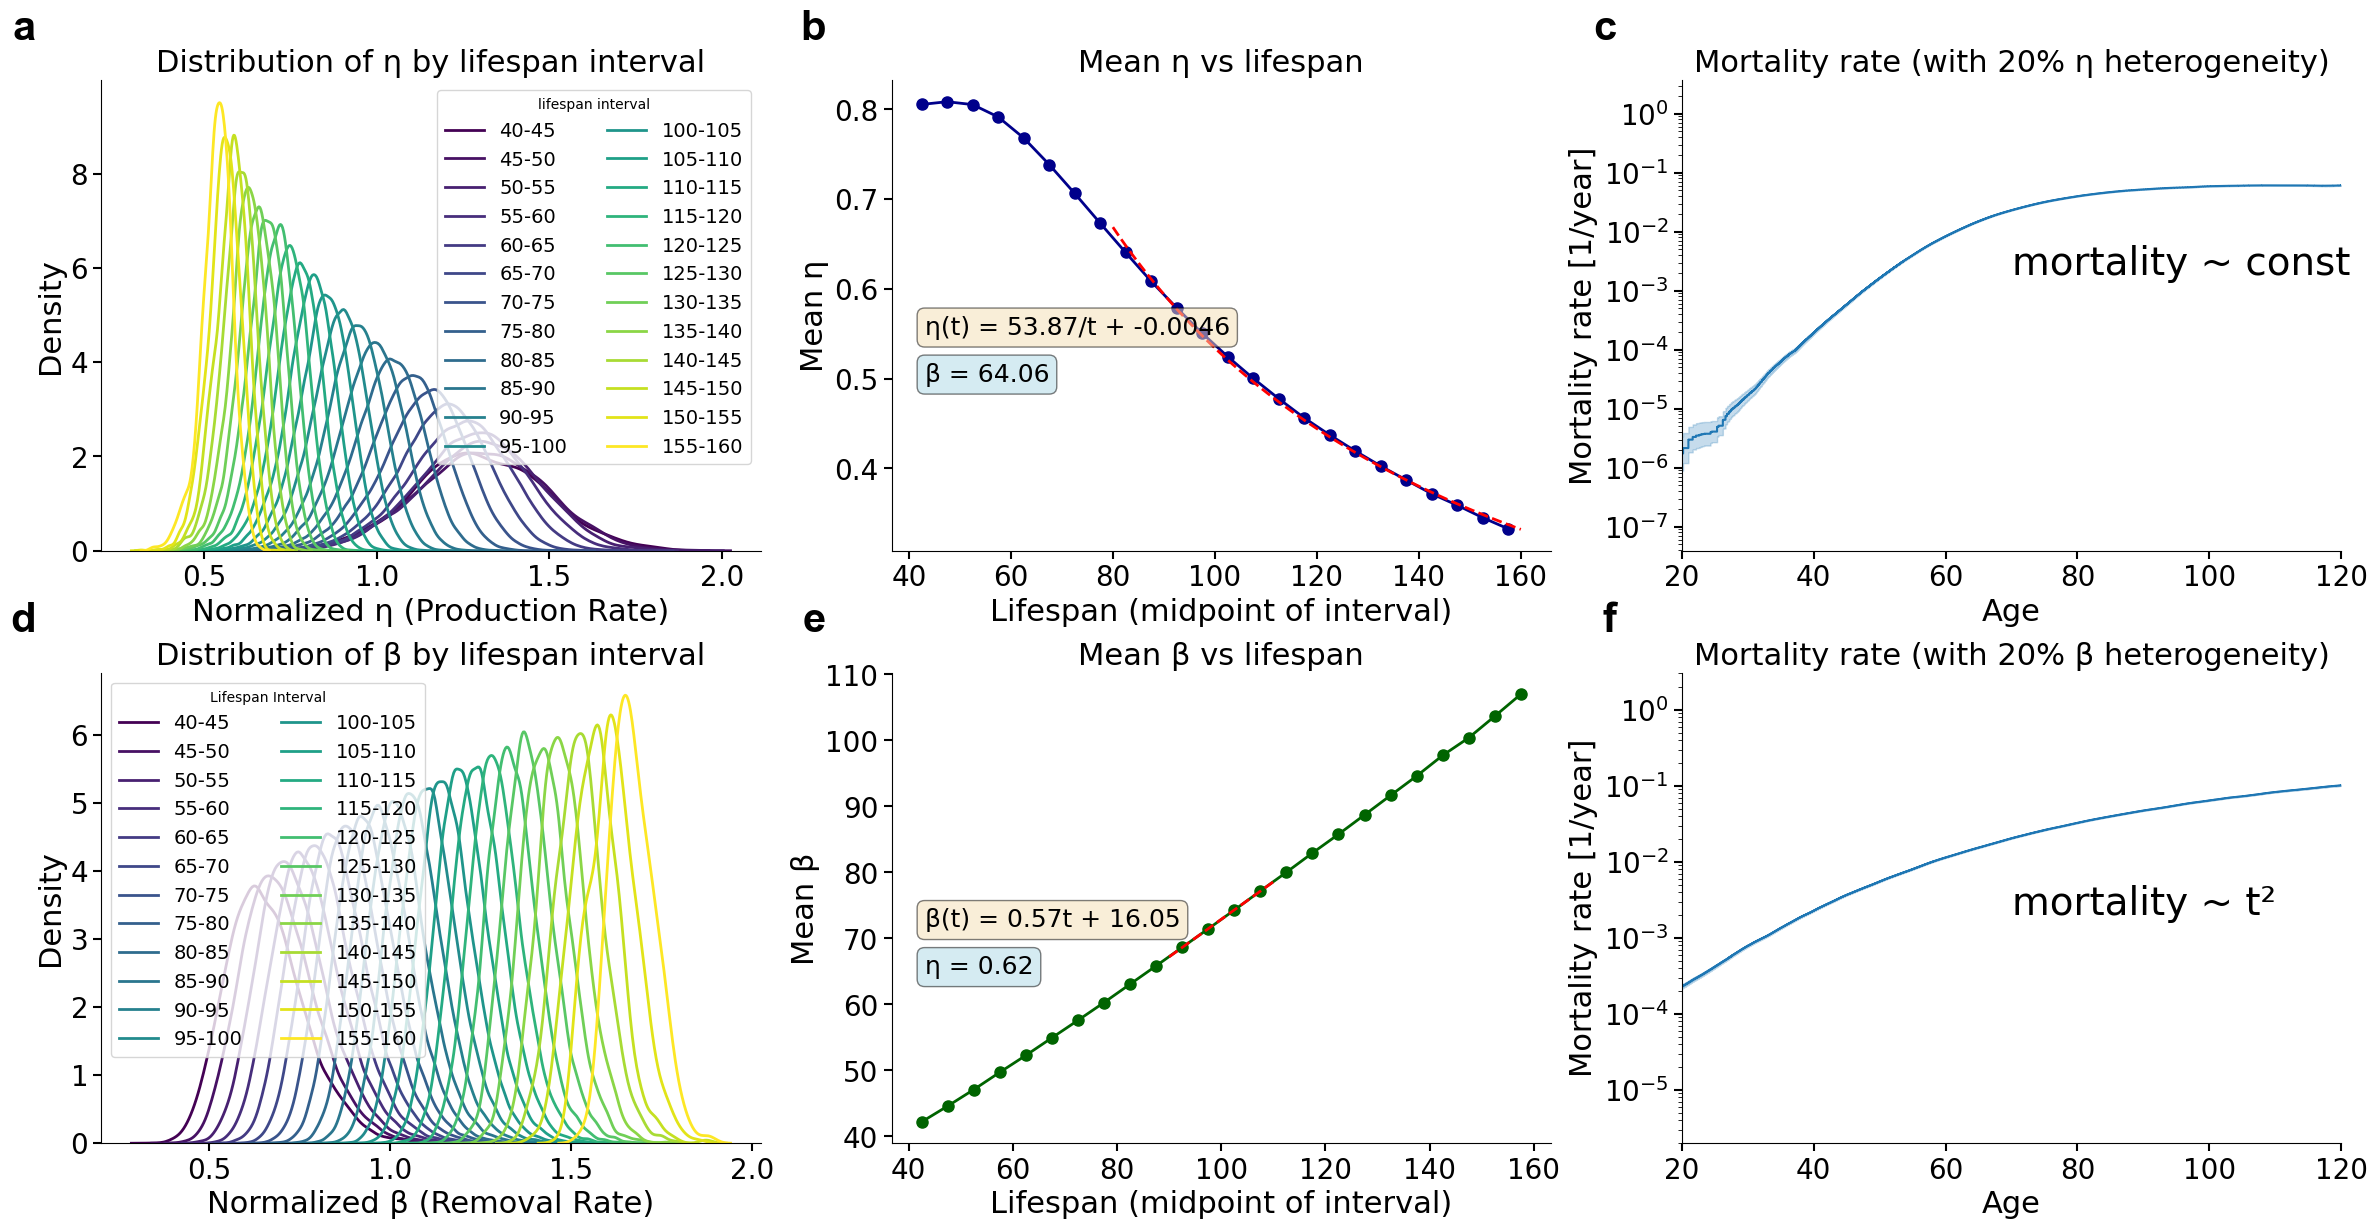

In [63]:
# Formatting parameters
TITLE_FONTSIZE = 22
AXIS_LABEL_FONTSIZE = 22
TICK_LABEL_FONTSIZE = 20
LEGEND_FONTSIZE = 14
EQUATION_FONTSIZE = 18
TEXT_BOX_X = 0.05
TEXT_BOX_Y = 0.40
PANEL_LABEL_FONTSIZE = 30
PANEL_LABEL_Y = 1.15  # Higher position for panel labels

# Create intervals
intervals = [(i, i+5) for i in range(40, 160, 5)]
colors = plt.cm.viridis(np.linspace(0, 1, len(intervals)))

# Helper function to plot KDE distributions by interval
def plot_param_kde_by_interval(sim, param_name, intervals, colors, ax, normalize=True):
    param_values = getattr(sim.params, param_name)
    mean_all = param_values.mean()
    mean_vals = []
    midpoints = []
    
    for idx, (start, end) in enumerate(intervals):
        mask = (sim.death_times >= start) & (sim.death_times < end)
        vals_in_interval = param_values[mask]
        
        if len(vals_in_interval) > 0:
            vals_to_plot = vals_in_interval / mean_all if normalize else vals_in_interval
            sns.kdeplot(vals_to_plot, ax=ax, color=colors[idx], 
                       label=f'{start}-{end}', linewidth=2, warn_singular=False)
            mean_vals.append(np.mean(vals_in_interval))
            midpoints.append((start + end) / 2)
    
    return np.array(midpoints), np.array(mean_vals)

# Helper function to fit and plot curve
def fit_and_plot_curve(midpoints, mean_vals, fit_range, ax, curve_type='inverse', color='red'):
    mask = (midpoints >= fit_range[0]) & (midpoints <= fit_range[1])
    if np.sum(mask) > 1:
        if curve_type == 'inverse':
            def func(t, a, b): return a + b / t
            popt, _ = curve_fit(func, midpoints[mask], mean_vals[mask])
            x_fit = np.linspace(fit_range[0], fit_range[1], 100)
            ax.plot(x_fit, func(x_fit, *popt), '--', linewidth=2, color=color)
            return popt, f'{popt[1]:.2f}/t + {popt[0]:.4f}'
        else:  # linear
            coeffs = np.polyfit(midpoints[mask], mean_vals[mask], 1)
            x_fit = np.linspace(fit_range[0], fit_range[1], 100)
            ax.plot(x_fit, np.poly1d(coeffs)(x_fit), '--', linewidth=2, color=color)
            return coeffs, f'{coeffs[0]:.2f}t + {coeffs[1]:.2f}'
    return None, None

# Create figure
fig, ((ax1, ax2, ax5), (ax3, ax4, ax6)) = plt.subplots(2, 3, figsize=(24, 12))

# Eta plots
midpoints_eta, mean_etas = plot_param_kde_by_interval(eta_sim, 'eta', intervals, colors, ax1)
ax1.set_xlabel('Normalized η (Production Rate)', fontsize=AXIS_LABEL_FONTSIZE)
ax1.set_ylabel('Density', fontsize=AXIS_LABEL_FONTSIZE)
ax1.set_title('Distribution of η by lifespan interval', fontsize=TITLE_FONTSIZE)
ax1.legend(title='lifespan interval', fontsize=LEGEND_FONTSIZE, ncol=2)
ax1.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)

ax2.plot(midpoints_eta, mean_etas, 'o-', linewidth=2, markersize=8, color='darkblue')
params_eta, eq_eta = fit_and_plot_curve(midpoints_eta, mean_etas, (80, 160), ax2, 'inverse')
if eq_eta:
    ax2.text(TEXT_BOX_X, TEXT_BOX_Y + 0.10, f'η(t) = {eq_eta}', transform=ax2.transAxes, 
             fontsize=EQUATION_FONTSIZE, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax2.text(TEXT_BOX_X, TEXT_BOX_Y, f'β = {eta_sim.params.beta.mean():.2f}', 
             transform=ax2.transAxes, fontsize=EQUATION_FONTSIZE, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax2.set_xlabel('Lifespan (midpoint of interval)', fontsize=AXIS_LABEL_FONTSIZE)
ax2.set_ylabel('Mean η', fontsize=AXIS_LABEL_FONTSIZE)
ax2.set_title('Mean η vs lifespan', fontsize=TITLE_FONTSIZE)
ax2.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)

eta_plotter = SR_plotting(eta_sim)
eta_plotter.plot_hazard(ax=ax5, label = 'None')
ax5.get_legend().remove()
ax5.set_xlim(20, 120)
ax5.set_xlabel('Age', fontsize=AXIS_LABEL_FONTSIZE)
ax5.set_ylabel('Mortality rate [1/year]', fontsize=AXIS_LABEL_FONTSIZE)
ax5.set_title('Mortality rate (with 20% η heterogeneity)', fontsize=TITLE_FONTSIZE)
ax5.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)
ax5.grid(False)
ax5.text(0.50, 0.65, 'mortality ~ const', transform=ax5.transAxes, 
         fontsize=EQUATION_FONTSIZE+10, verticalalignment='top')

# Beta plots
midpoints_beta, mean_betas = plot_param_kde_by_interval(beta_sim, 'beta', intervals, colors, ax3)
ax3.set_xlabel('Normalized β (Removal Rate)', fontsize=AXIS_LABEL_FONTSIZE)
ax3.set_ylabel('Density', fontsize=AXIS_LABEL_FONTSIZE)
ax3.set_title('Distribution of β by lifespan interval', fontsize=TITLE_FONTSIZE)
ax3.legend(title='Lifespan Interval', fontsize=LEGEND_FONTSIZE, ncol=2)
ax3.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)

ax4.plot(midpoints_beta, mean_betas, 'o-', linewidth=2, markersize=8, color='darkgreen')
params_beta, eq_beta = fit_and_plot_curve(midpoints_beta, mean_betas, (90, 110), ax4, 'linear')
if eq_beta:
    ax4.text(TEXT_BOX_X, TEXT_BOX_Y + 0.10, f'β(t) = {eq_beta}', transform=ax4.transAxes, 
             fontsize=EQUATION_FONTSIZE, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax4.text(TEXT_BOX_X, TEXT_BOX_Y, f'η = {beta_sim.params.eta.mean():.2f}', 
             transform=ax4.transAxes, fontsize=EQUATION_FONTSIZE, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax4.set_xlabel('Lifespan (midpoint of interval)', fontsize=AXIS_LABEL_FONTSIZE)
ax4.set_ylabel('Mean β', fontsize=AXIS_LABEL_FONTSIZE)
ax4.set_title('Mean β vs lifespan', fontsize=TITLE_FONTSIZE)
ax4.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)

beta_plotter = SR_plotting(beta_sim)
beta_plotter.plot_hazard(ax=ax6)
ax6.set_xlim(20, 120)
ax6.set_xlabel('Age', fontsize=AXIS_LABEL_FONTSIZE)
ax6.set_ylabel('Mortality rate [1/year]', fontsize=AXIS_LABEL_FONTSIZE)
ax6.set_title('Mortality rate (with 20% β heterogeneity)', fontsize=TITLE_FONTSIZE)
ax6.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)
ax6.get_legend().remove()
ax6.grid(False)

ax6.text(0.50, 0.55, 'mortality ~ t²', transform=ax6.transAxes, 
         fontsize=EQUATION_FONTSIZE+10, verticalalignment='top')

plt.tight_layout()

# Add panel labels at the end
ax1.text(-0.1, PANEL_LABEL_Y, 'a', transform=ax1.transAxes, fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='bold', va='top', ha='right', family='Arial')
ax2.text(-0.1, PANEL_LABEL_Y, 'b', transform=ax2.transAxes, fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='bold', va='top', ha='right', family='Arial')
ax3.text(-0.1, PANEL_LABEL_Y, 'd', transform=ax3.transAxes, fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='bold', va='top', ha='right', family='Arial')
ax4.text(-0.1, PANEL_LABEL_Y, 'e', transform=ax4.transAxes, fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='bold', va='top', ha='right', family='Arial')
ax5.text(-0.1, PANEL_LABEL_Y, 'c', transform=ax5.transAxes, fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='bold', va='top', ha='right', family='Arial')
ax6.text(-0.1, PANEL_LABEL_Y, 'f', transform=ax6.transAxes, fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='bold', va='top', ha='right', family='Arial')

plt.show()


/var/folders/cn/lhb2c_1j601c1tw27_rr981m0000gp/T/ipykernel_23841/2228841398.py:203: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


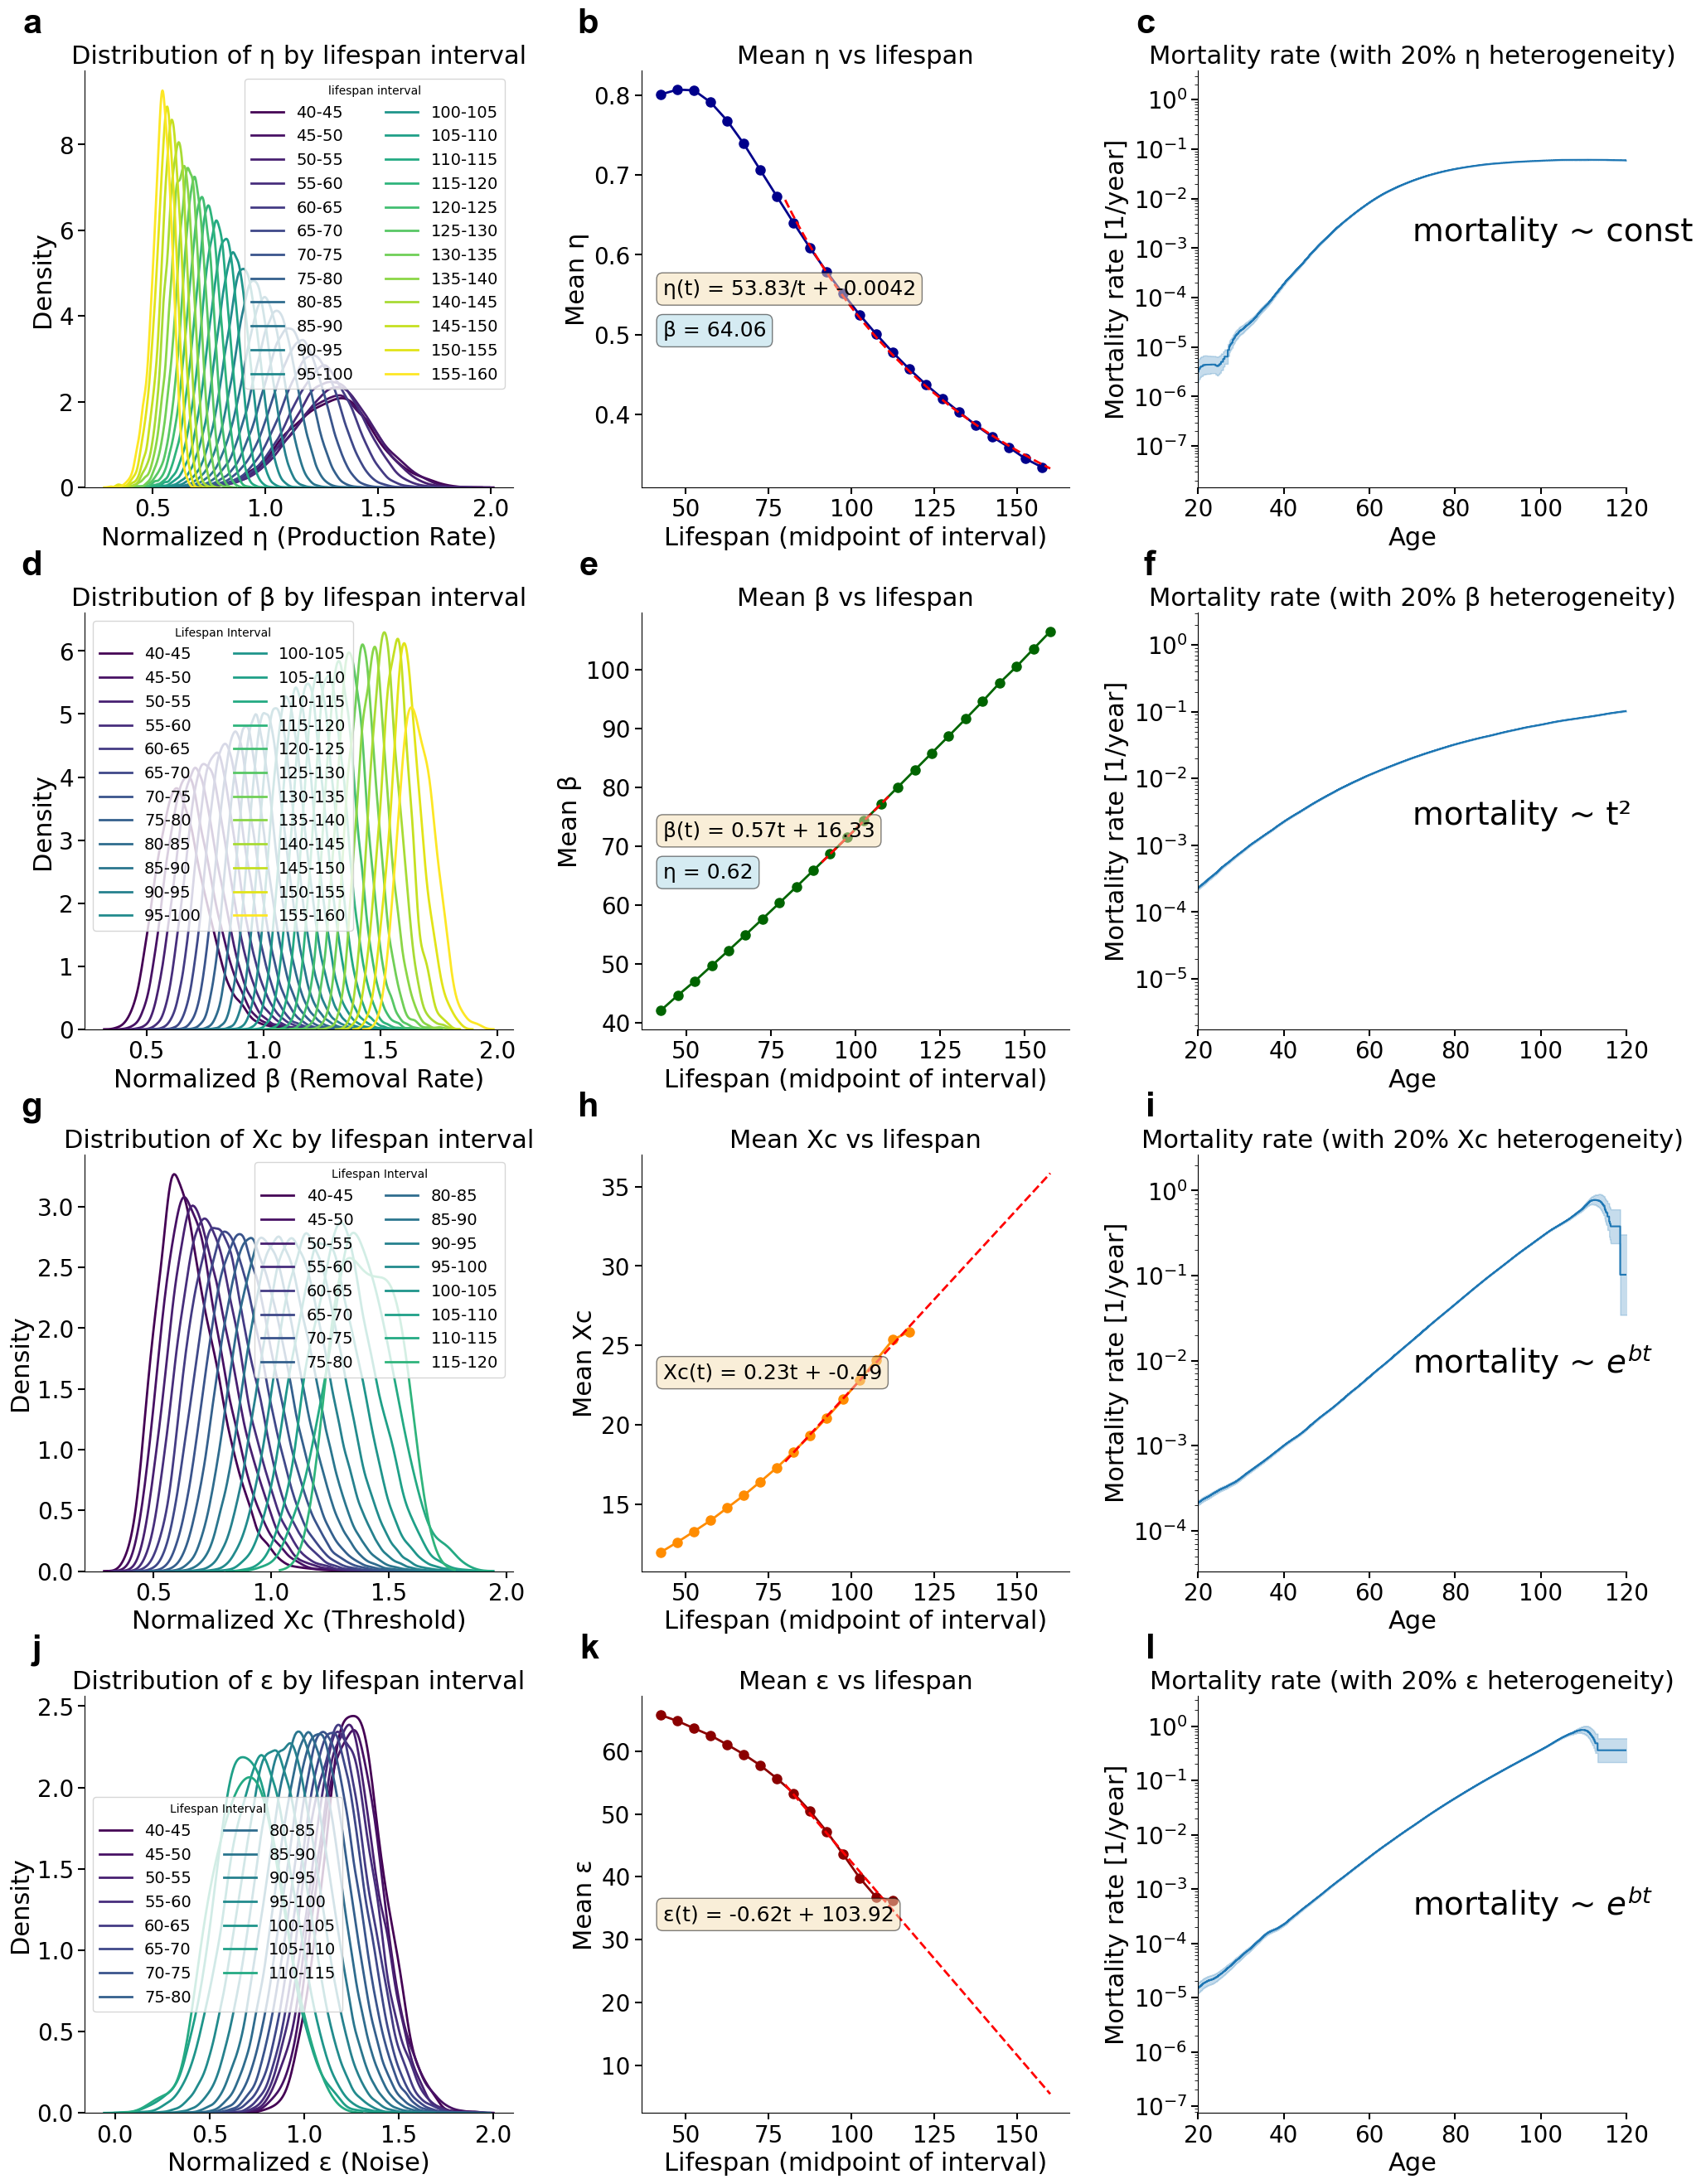

In [66]:
# Formatting parameters
TITLE_FONTSIZE = 22
AXIS_LABEL_FONTSIZE = 22
TICK_LABEL_FONTSIZE = 20
LEGEND_FONTSIZE = 14
EQUATION_FONTSIZE = 18
TEXT_BOX_X = 0.05
TEXT_BOX_Y = 0.40
PANEL_LABEL_FONTSIZE = 30
PANEL_LABEL_Y = 1.15  # Higher position for panel labels

# Create intervals
intervals = [(i, i+5) for i in range(40, 160, 5)]
colors = plt.cm.viridis(np.linspace(0, 1, len(intervals)))

# Helper function to plot KDE distributions by interval
def plot_param_kde_by_interval(sim, param_name, intervals, colors, ax, normalize=True):
    param_values = getattr(sim.params, param_name)
    mean_all = param_values.mean()
    mean_vals = []
    midpoints = []
    
    for idx, (start, end) in enumerate(intervals):
        mask = (sim.death_times >= start) & (sim.death_times < end)
        vals_in_interval = param_values[mask]
        
        if len(vals_in_interval) > 0:
            vals_to_plot = vals_in_interval / mean_all if normalize else vals_in_interval
            sns.kdeplot(vals_to_plot, ax=ax, color=colors[idx], 
                       label=f'{start}-{end}', linewidth=2, warn_singular=False)
            mean_vals.append(np.mean(vals_in_interval))
            midpoints.append((start + end) / 2)
    
    return np.array(midpoints), np.array(mean_vals)

# Helper function to fit and plot curve
def fit_and_plot_curve(midpoints, mean_vals, fit_range, ax, curve_type='inverse', color='red'):
    mask = (midpoints >= fit_range[0]) & (midpoints <= fit_range[1])
    if np.sum(mask) > 1:
        if curve_type == 'inverse':
            def func(t, a, b): return a + b / t
            popt, _ = curve_fit(func, midpoints[mask], mean_vals[mask])
            x_fit = np.linspace(fit_range[0], fit_range[1], 100)
            ax.plot(x_fit, func(x_fit, *popt), '--', linewidth=2, color=color)
            return popt, f'{popt[1]:.2f}/t + {popt[0]:.4f}'
        else:  # linear
            coeffs = np.polyfit(midpoints[mask], mean_vals[mask], 1)
            x_fit = np.linspace(fit_range[0], fit_range[1], 100)
            ax.plot(x_fit, np.poly1d(coeffs)(x_fit), '--', linewidth=2, color=color)
            return coeffs, f'{coeffs[0]:.2f}t + {coeffs[1]:.2f}'
    return None, None

# Create figure with 4 rows and 3 columns
fig = plt.figure(figsize=(24, 32))
gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax5 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 0])
ax8 = fig.add_subplot(gs[2, 1])
ax9 = fig.add_subplot(gs[2, 2])
ax10 = fig.add_subplot(gs[3, 0])
ax11 = fig.add_subplot(gs[3, 1])
ax12 = fig.add_subplot(gs[3, 2])

# Eta plots
midpoints_eta, mean_etas = plot_param_kde_by_interval(eta_sim, 'eta', intervals, colors, ax1)
ax1.set_xlabel('Normalized η (Production Rate)', fontsize=AXIS_LABEL_FONTSIZE)
ax1.set_ylabel('Density', fontsize=AXIS_LABEL_FONTSIZE)
ax1.set_title('Distribution of η by lifespan interval', fontsize=TITLE_FONTSIZE)
ax1.legend(title='lifespan interval', fontsize=LEGEND_FONTSIZE, ncol=2)
ax1.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)

ax2.plot(midpoints_eta, mean_etas, 'o-', linewidth=2, markersize=8, color='darkblue')
params_eta, eq_eta = fit_and_plot_curve(midpoints_eta, mean_etas, (80, 160), ax2, 'inverse')
if eq_eta:
    ax2.text(TEXT_BOX_X, TEXT_BOX_Y + 0.10, f'η(t) = {eq_eta}', transform=ax2.transAxes, 
             fontsize=EQUATION_FONTSIZE, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax2.text(TEXT_BOX_X, TEXT_BOX_Y, f'β = {eta_sim.params.beta.mean():.2f}', 
             transform=ax2.transAxes, fontsize=EQUATION_FONTSIZE, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax2.set_xlabel('Lifespan (midpoint of interval)', fontsize=AXIS_LABEL_FONTSIZE)
ax2.set_ylabel('Mean η', fontsize=AXIS_LABEL_FONTSIZE)
ax2.set_title('Mean η vs lifespan', fontsize=TITLE_FONTSIZE)
ax2.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)

eta_plotter = SR_plotting(eta_sim)
eta_plotter.plot_hazard(ax=ax5, label = 'None')
ax5.get_legend().remove()
ax5.set_xlim(20, 120)
ax5.set_xlabel('Age', fontsize=AXIS_LABEL_FONTSIZE)
ax5.set_ylabel('Mortality rate [1/year]', fontsize=AXIS_LABEL_FONTSIZE)
ax5.set_title('Mortality rate (with 20% η heterogeneity)', fontsize=TITLE_FONTSIZE)
ax5.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)
ax5.grid(False)
ax5.text(0.50, 0.65, 'mortality ~ const', transform=ax5.transAxes, 
         fontsize=EQUATION_FONTSIZE+10, verticalalignment='top')

# Beta plots
midpoints_beta, mean_betas = plot_param_kde_by_interval(beta_sim, 'beta', intervals, colors, ax3)
ax3.set_xlabel('Normalized β (Removal Rate)', fontsize=AXIS_LABEL_FONTSIZE)
ax3.set_ylabel('Density', fontsize=AXIS_LABEL_FONTSIZE)
ax3.set_title('Distribution of β by lifespan interval', fontsize=TITLE_FONTSIZE)
ax3.legend(title='Lifespan Interval', fontsize=LEGEND_FONTSIZE, ncol=2)
ax3.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)

ax4.plot(midpoints_beta, mean_betas, 'o-', linewidth=2, markersize=8, color='darkgreen')
params_beta, eq_beta = fit_and_plot_curve(midpoints_beta, mean_betas, (90, 110), ax4, 'linear')
if eq_beta:
    ax4.text(TEXT_BOX_X, TEXT_BOX_Y + 0.10, f'β(t) = {eq_beta}', transform=ax4.transAxes, 
             fontsize=EQUATION_FONTSIZE, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax4.text(TEXT_BOX_X, TEXT_BOX_Y, f'η = {beta_sim.params.eta.mean():.2f}', 
             transform=ax4.transAxes, fontsize=EQUATION_FONTSIZE, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax4.set_xlabel('Lifespan (midpoint of interval)', fontsize=AXIS_LABEL_FONTSIZE)
ax4.set_ylabel('Mean β', fontsize=AXIS_LABEL_FONTSIZE)
ax4.set_title('Mean β vs lifespan', fontsize=TITLE_FONTSIZE)
ax4.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)

beta_plotter = SR_plotting(beta_sim)
beta_plotter.plot_hazard(ax=ax6)
ax6.set_xlim(20, 120)
ax6.set_xlabel('Age', fontsize=AXIS_LABEL_FONTSIZE)
ax6.set_ylabel('Mortality rate [1/year]', fontsize=AXIS_LABEL_FONTSIZE)
ax6.set_title('Mortality rate (with 20% β heterogeneity)', fontsize=TITLE_FONTSIZE)
ax6.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)
ax6.get_legend().remove()
ax6.grid(False)

ax6.text(0.50, 0.55, 'mortality ~ t²', transform=ax6.transAxes, 
         fontsize=EQUATION_FONTSIZE+10, verticalalignment='top')

# Xc plots
midpoints_xc, mean_xcs = plot_param_kde_by_interval(Xc_sim, 'Xc', intervals, colors, ax7)
ax7.set_xlabel('Normalized Xc (Threshold)', fontsize=AXIS_LABEL_FONTSIZE)
ax7.set_ylabel('Density', fontsize=AXIS_LABEL_FONTSIZE)
ax7.set_title('Distribution of Xc by lifespan interval', fontsize=TITLE_FONTSIZE)
ax7.legend(title='Lifespan Interval', fontsize=LEGEND_FONTSIZE, ncol=2)
ax7.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)

ax8.plot(midpoints_xc, mean_xcs, 'o-', linewidth=2, markersize=8, color='darkorange')
params_xc, eq_xc = fit_and_plot_curve(midpoints_xc, mean_xcs, (80, 160), ax8, 'linear')
if eq_xc:
    ax8.text(TEXT_BOX_X, TEXT_BOX_Y + 0.10, f'Xc(t) = {eq_xc}', transform=ax8.transAxes, 
             fontsize=EQUATION_FONTSIZE, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax8.set_xlabel('Lifespan (midpoint of interval)', fontsize=AXIS_LABEL_FONTSIZE)
ax8.set_ylabel('Mean Xc', fontsize=AXIS_LABEL_FONTSIZE)
ax8.set_title('Mean Xc vs lifespan', fontsize=TITLE_FONTSIZE)
ax8.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)

xc_plotter = SR_plotting(Xc_sim)
xc_plotter.plot_hazard(ax=ax9)
ax9.set_xlim(20, 120)
ax9.set_xlabel('Age', fontsize=AXIS_LABEL_FONTSIZE)
ax9.set_ylabel('Mortality rate [1/year]', fontsize=AXIS_LABEL_FONTSIZE)
ax9.set_title('Mortality rate (with 20% Xc heterogeneity)', fontsize=TITLE_FONTSIZE)
ax9.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)
ax9.get_legend().remove()
ax9.grid(False)

ax9.text(0.50, 0.55, r'mortality ~ $e^{bt}$', transform=ax9.transAxes, 
         fontsize=EQUATION_FONTSIZE+10, verticalalignment='top')

# Epsilon plots
midpoints_eps, mean_epss = plot_param_kde_by_interval(epsilon_sim, 'epsilon', intervals, colors, ax10)
ax10.set_xlabel('Normalized ε (Noise)', fontsize=AXIS_LABEL_FONTSIZE)
ax10.set_ylabel('Density', fontsize=AXIS_LABEL_FONTSIZE)
ax10.set_title('Distribution of ε by lifespan interval', fontsize=TITLE_FONTSIZE)
ax10.legend(title='Lifespan Interval', fontsize=LEGEND_FONTSIZE, ncol=2)
ax10.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)

ax11.plot(midpoints_eps, mean_epss, 'o-', linewidth=2, markersize=8, color='darkred')
params_eps, eq_eps = fit_and_plot_curve(midpoints_eps, mean_epss, (80, 160), ax11, 'linear')
if eq_eps:
    ax11.text(TEXT_BOX_X, TEXT_BOX_Y + 0.10, f'ε(t) = {eq_eps}', transform=ax11.transAxes, 
             fontsize=EQUATION_FONTSIZE, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax11.set_xlabel('Lifespan (midpoint of interval)', fontsize=AXIS_LABEL_FONTSIZE)
ax11.set_ylabel('Mean ε', fontsize=AXIS_LABEL_FONTSIZE)
ax11.set_title('Mean ε vs lifespan', fontsize=TITLE_FONTSIZE)
ax11.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)

eps_plotter = SR_plotting(epsilon_sim)
eps_plotter.plot_hazard(ax=ax12)
ax12.set_xlim(20, 120)
ax12.set_xlabel('Age', fontsize=AXIS_LABEL_FONTSIZE)
ax12.set_ylabel('Mortality rate [1/year]', fontsize=AXIS_LABEL_FONTSIZE)
ax12.set_title('Mortality rate (with 20% ε heterogeneity)', fontsize=TITLE_FONTSIZE)
ax12.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)
ax12.get_legend().remove()
ax12.grid(False)

ax12.text(0.50, 0.55, r'mortality ~ $e^{bt}$', transform=ax12.transAxes, 
         fontsize=EQUATION_FONTSIZE+10, verticalalignment='top')

plt.tight_layout()

# Add panel labels at the end
ax1.text(-0.1, PANEL_LABEL_Y, 'a', transform=ax1.transAxes, fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='bold', va='top', ha='right', family='Arial')
ax2.text(-0.1, PANEL_LABEL_Y, 'b', transform=ax2.transAxes, fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='bold', va='top', ha='right', family='Arial')
ax3.text(-0.1, PANEL_LABEL_Y, 'd', transform=ax3.transAxes, fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='bold', va='top', ha='right', family='Arial')
ax4.text(-0.1, PANEL_LABEL_Y, 'e', transform=ax4.transAxes, fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='bold', va='top', ha='right', family='Arial')
ax5.text(-0.1, PANEL_LABEL_Y, 'c', transform=ax5.transAxes, fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='bold', va='top', ha='right', family='Arial')
ax6.text(-0.1, PANEL_LABEL_Y, 'f', transform=ax6.transAxes, fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='bold', va='top', ha='right', family='Arial')
ax7.text(-0.1, PANEL_LABEL_Y, 'g', transform=ax7.transAxes, fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='bold', va='top', ha='right', family='Arial')
ax8.text(-0.1, PANEL_LABEL_Y, 'h', transform=ax8.transAxes, fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='bold', va='top', ha='right', family='Arial')
ax9.text(-0.1, PANEL_LABEL_Y, 'i', transform=ax9.transAxes, fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='bold', va='top', ha='right', family='Arial')
ax10.text(-0.1, PANEL_LABEL_Y, 'j', transform=ax10.transAxes, fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='bold', va='top', ha='right', family='Arial')
ax11.text(-0.1, PANEL_LABEL_Y, 'k', transform=ax11.transAxes, fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='bold', va='top', ha='right', family='Arial')
ax12.text(-0.1, PANEL_LABEL_Y, 'l', transform=ax12.transAxes, fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='bold', va='top', ha='right', family='Arial')

plt.show()


In [68]:
eta_sim.params.eta.mean()

0.620676314523743

9.188335298746812e-07


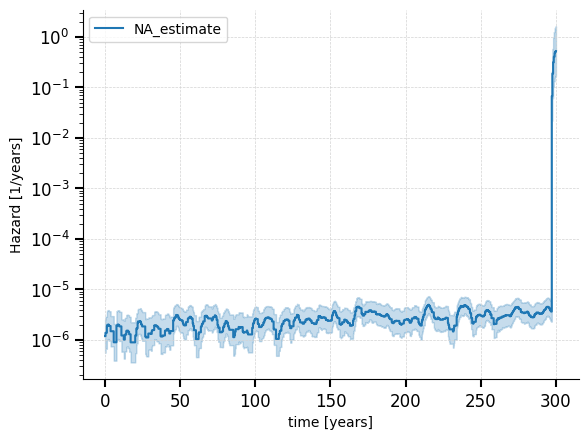

In [80]:
# Define and rerun eta_sim
n = int(1e6)

base_dict = utils.load_baseline_human_params_dict()
base_dict['eta'] = 1e-2

test_sim = utils.create_sr_simulation(params_dict=base_dict, n=n, parallel=True, tmax=300, break_early=True)
plotter = SR_plotting(test_sim)
plotter.plot_hazard()


beta = test_sim.params.beta.mean()
Xc = test_sim.params.Xc.mean()
epsilon = test_sim.params.epsilon.mean()
eta = test_sim.params.eta.mean()

print(beta**2/epsilon * np.exp(-beta*Xc/epsilon))




In [86]:
np.sqrt(-np.log(0.73) / (2*400*20*2**20))

4.331076327331225e-06